<a href="https://colab.research.google.com/github/shahwaiz-9/Deep-Learning/blob/main/Multi_class_classification_(_CNN_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abtabm/multiclassimagedatasetairplanecar")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'multiclassimagedatasetairplanecar' dataset.
Path to dataset files: /kaggle/input/multiclassimagedatasetairplanecar


In [2]:
import os

# List the contents of the downloaded dataset directory
print(os.listdir(path))

['Dataset']


In [3]:
dataset_dir = os.path.join(path, 'Dataset')
print(os.listdir(dataset_dir))

['test', 'train']


In [4]:
train_dir = os.path.join(dataset_dir, 'train')
print("Contents of train directory:", os.listdir(train_dir))

Contents of train directory: ['airplanes', 'ship', 'cars']


In [5]:
test_dir = os.path.join(dataset_dir, 'test')
print("Contents of test directory:", os.listdir(test_dir))

Contents of test directory: ['airplanes', 'ships', 'cars']


In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np


In [11]:

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

CLASS_NAMES = None

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASS_NAMES,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASS_NAMES,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nTraining dataset class names:", train_ds.class_names)
print("Validation dataset class names:", val_ds.class_names)


for images, labels in train_ds.take(1):
    print(f"\nShape of image batch: {images.shape}")
    print(f"Shape of label batch: {labels.shape}")
    print(f"Sample labels: {labels.numpy().flatten()}")

Found 3000 files belonging to 3 classes.
Found 582 files belonging to 3 classes.

Training dataset class names: ['airplanes', 'cars', 'ship']
Validation dataset class names: ['airplanes', 'cars', 'ships']

Shape of image batch: (32, 224, 224, 3)
Shape of label batch: (32, 3)
Sample labels: [0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1.
 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1.
 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0.
 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0.]


In [16]:



def build_model(input_Shape):

  model = Sequential()
  model.add(layers.Rescaling(1./255, input_shape=input_Shape))


  # CNN Part
  model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape= input_Shape))
  model.add(layers.MaxPool2D((2,2))) # Half the size


  model.add(layers.Conv2D(64, (3, 3), activation='relu'))
  model.add(layers.MaxPool2D((2,2)))

  # ANN part

  model.add(layers.Flatten())
  model.add(layers.Dense(64, activation='relu'))
  model.add(layers.Dense(3, activation='softmax'))

  model.compile(
      optimizer='adam',
      loss = 'categorical_crossentropy',
      metrics=['accuracy']
  )

  print(model.summary())

  return model

In [17]:
model = build_model((224,224,3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,963,587 (45.64 MB)

 Trainable params: 11,963,587 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

None


In [18]:
history = model.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds
)

Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 303s 3s/step - accuracy: 0.6843 - loss: 0.9973 - val_accuracy: 0.7715 - val_loss: 0.5019
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 307s 3s/step - accuracy: 0.8850 - loss: 0.3036 - val_accuracy: 0.8625 - val_loss: 0.3781
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 297s 3s/step - accuracy: 0.9480 - loss: 0.1542 - val_accuracy: 0.8351 - val_loss: 0.5025
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 312s 3s/step - accuracy: 0.9740 - loss: 0.0803 - val_accuracy: 0.8694 - val_loss: 0.3899
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 300s 3s/step - accuracy: 0.9933 - loss: 0.0250 - val_accuracy: 0.8660 - val_loss: 0.4966


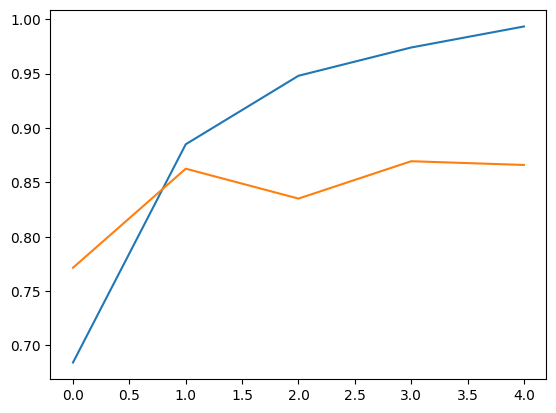

In [22]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

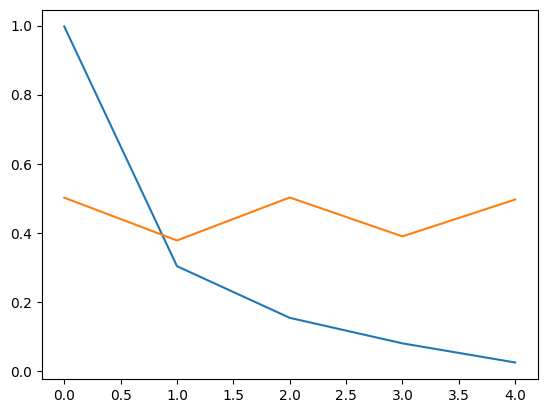

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [19]:

def build_optimized1_model(input_shape):

    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])


    model = keras.Sequential([
        layers.Rescaling(1./255, input_shape=input_shape),

        # CNN layers
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPool2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPool2D((2, 2)),

        # ANN layers
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.summary()
    return model


In [20]:
new_model = build_optimized1_model((224,224,3))

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,963,587 (45.64 MB)

 Trainable params: 11,963,587 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history1 = new_model.fit(
    train_ds,
    epochs=3,
    validation_data=val_ds
)

Epoch 1/3
94/94 ━━━━━━━━━━━━━━━━━━━━ 294s 3s/step - accuracy: 0.5940 - loss: 1.3005 - val_accuracy: 0.7663 - val_loss: 0.6294
Epoch 2/3
94/94 ━━━━━━━━━━━━━━━━━━━━ 328s 3s/step - accuracy: 0.8140 - loss: 0.4941 - val_accuracy: 0.8918 - val_loss: 0.3451
Epoch 3/3
94/94 ━━━━━━━━━━━━━━━━━━━━ 283s 3s/step - accuracy: 0.8893 - loss: 0.3205 - val_accuracy: 0.9003 - val_loss: 0.3027


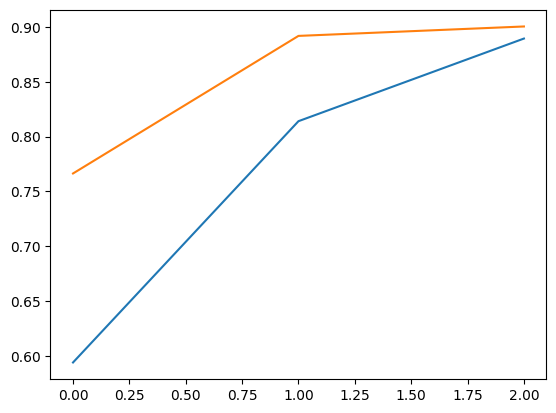

In [24]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])

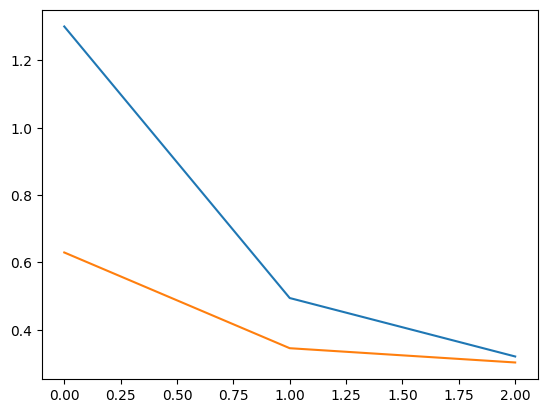

In [25]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

Dropout and Augmentation worked very well non this.
Since features are discovered by Neural Network internally we cannot say exactly what is happenening inside. Therefore we have to apply every thing in the bag and select the one which gives best results.